In [42]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs("figures", exist_ok=True)

# Если forecasts еще не загружены – загружаем из CSV
if 'forecasts' not in globals():
    forecasts = {}
    for cls in ['all', 'Smooth', 'Erratic', 'Intermittent', 'Lumpy']:
        try:
            forecasts[cls] = pd.read_csv(f'forecasts_{cls}.csv', parse_dates=['ds'])
            print(f"Загружен forecasts_{cls}.csv : {forecasts[cls].shape}")
        except FileNotFoundError:
            print(f"Файл forecasts_{cls}.csv не найден, буду использовать all_results")
            if 'all_results' in globals() and cls in all_results:
                forecasts[cls] = all_results[cls]['forecast']
                print(f"Взят из all_results для класса {cls}, форма {forecasts[cls].shape}")
            else:
                forecasts[cls] = pd.DataFrame()

In [22]:
# ------------------------------------------------------------------
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ------------------------------------------------------------------
def load_and_preprocess(file_path):
    """Загрузка и предобработка данных"""
    df = pd.read_excel(file_path)
    df = df.drop_duplicates()

    # Создание unique_id
    df["unique_id"] = (
        df["id"].astype(str) + "_" +
        df["Код филиала"].astype(str) + "_" +
        df["Код ЦФО"].astype(str)
    )

    # Берём оба показателя (ДЗ н.п. и ДЗ к.п.)
    df_both = df[df["Показатель"].isin(["ДЗ н.п.", "ДЗ к.п."])]

    # Преобразование в длинный формат
    id_vars = ["id", "Код филиала", "Код ЦФО", "Показатель", "number", "unique_id"]
    df_long = pd.melt(df_both, id_vars=id_vars, var_name="month", value_name="y")

    # Функция для корректного создания дат
    def get_date(row):
        month_num = int(row['month'])
        if month_num <= 12:
            year, month = 2022, month_num
        else:
            year, month = 2023, month_num - 12

        if row['Показатель'] == 'ДЗ н.п.':
            return pd.Timestamp(f"{year}-{month:02d}-01")
        else:
            if month == 12:
                next_year, next_month = year + 1, 1
            else:
                next_year, next_month = year, month + 1
            next_month_start = pd.Timestamp(f"{next_year}-{next_month:02d}-01")
            return next_month_start - pd.Timedelta(days=1)

    df_long['ds'] = df_long.apply(get_date, axis=1)

    # Фильтрация нулевых рядов
    mask = df_long.groupby("unique_id")["y"].transform("sum") != 0
    df_long = df_long[mask].sort_values(["unique_id", "ds"])

    # Создание объединtнного ряда (ДЗ н.п. + ДЗ к.п. со сдвигом)
    df_start = df_long[df_long['Показатель'] == 'ДЗ н.п.'].copy()
    df_end = df_long[df_long['Показатель'] == 'ДЗ к.п.'].copy()
    df_end['ds'] = df_end['ds'] + pd.offsets.MonthBegin(1)
    df_combined = pd.concat([df_start, df_end], ignore_index=True)
    df_combined = df_combined.sort_values(['unique_id', 'ds'])
    df_combined = df_combined.drop_duplicates(subset=['unique_id', 'ds'], keep='first')


    return df_combined[['unique_id', 'y', 'ds']]

In [23]:
# ------------------------------------------------------------------
# 2. КЛАССИФИКАЦИЯ РЯДОВ ПО МЕТОДИКЕ SYNTETOS/BOYLAN (ADI/CV²)
# ------------------------------------------------------------------

def classify_time_series(df_long):
    """Классификация временных рядов по ADI и CV²"""
    results = []

    for uid, group in df_long.groupby('unique_id'):
        T = len(group)
        non_zero_values = group[group['y'] > 0]['y']
        N = len(non_zero_values)

        # ADI (Average Demand Interval)
        if N == 0:
            adi = np.inf
        else:
            adi = T / N

        # CV² (Coefficient of Variation squared)
        if N == 0:
            cv2 = np.nan
        elif N == 1:
            cv2 = 0.0
        else:
            mean = non_zero_values.mean()
            std = non_zero_values.std(ddof=1)
            cv = std / mean if mean != 0 else np.inf
            cv2 = cv ** 2

        # Классификация
        adi_threshold, cv2_threshold = 1.32, 0.49

        if adi <= adi_threshold and cv2 <= cv2_threshold:
            demand_class = "Smooth"
        elif adi <= adi_threshold and cv2 > cv2_threshold:
            demand_class = "Erratic"
        elif adi > adi_threshold and cv2 <= cv2_threshold:
            demand_class = "Intermittent"
        elif adi > adi_threshold and cv2 > cv2_threshold:
            demand_class = "Lumpy"
        else:
            demand_class = "Undefined"

        results.append({'unique_id': uid, 'adi': adi, 'cv2': cv2, 'class': demand_class})

    return pd.DataFrame(results)



In [24]:
df_long = load_and_preprocess("data.xlsx")
classification_df = classify_time_series(df_long)

In [39]:
classes = ['all', 'Smooth', 'Erratic', 'Intermittent', 'Lumpy']

In [48]:
# -------------------------------------------------------------------
# 2. Функция для выборочного графика с полной историей и интервалами
# -------------------------------------------------------------------
def plot_full_series_with_forecast(unique_id, forecast_df, full_df, classification_df,
                                   models=['AutoARIMA', 'SES', 'NBEATS', 'AutoPatchTST', 'Chronos_tiny', 'DeepAR'],
                                   confidence_cols={'DeepAR': ('DeepAR-lo-90', 'DeepAR-hi-90')}):
    """
    unique_id : str
        Идентификатор ряда.
    forecast_df : DataFrame
        Прогнозы для данного класса (уже отфильтрованные по классу).
    full_df : DataFrame
        Полные исторические данные (колонки: unique_id, ds, y).
    classification_df : DataFrame
        Классификация рядов (unique_id, class).
    models : list
        Список моделей для отображения (должны быть колонками в forecast_df).
    confidence_cols : dict
        Для каждой модели, у которой есть интервалы, указать кортеж (lo_col, hi_col).
    """
    history = full_df[full_df['unique_id'] == unique_id].sort_values('ds').copy()
    pred = forecast_df[forecast_df['unique_id'] == unique_id].sort_values('ds').copy()

    if history.empty or pred.empty:
        print(f"Нет данных для {unique_id}")
        return

    cls = classification_df.loc[classification_df['unique_id'] == unique_id, 'class'].values[0]

    # Преобразуем даты в числовой формат для matplotlib
    history['ds_num'] = mdates.date2num(history['ds'])
    pred['ds_num'] = mdates.date2num(pred['ds'])

    plt.figure(figsize=(14, 6))
    plt.plot(history['ds_num'], history['y'], 'k-', linewidth=2, label='История (факт)')
    #plt.plot(pred['ds_num'], pred['y'], 'ko', markersize=4, label='Тест (факт)')

    for model in models:
        if model not in pred.columns:
            continue
        plt.plot(pred['ds_num'], pred[model], 'o--', linewidth=2, label=model, alpha=0.7)
        if model in confidence_cols:
            lo, hi = confidence_cols[model]
            if lo in pred.columns and hi in pred.columns:
                plt.fill_between(pred['ds_num'], pred[lo], pred[hi], alpha=0.2, label=f'{model} 90% CI')

    # Форматирование оси дат
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    plt.title(f'Ряд {unique_id} (класс {cls}) – полная история и прогнозы')
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"series_{unique_id}_{cls}.png", dpi=300, bbox_inches="tight")
    plt.show()



In [ ]:
# -------------------------------------------------------------------
# 3. Выбор репрезентативных рядов из каждого класса
# -------------------------------------------------------------------
# Для каждого класса выберем 2 ряда:
#   - один с медианной длиной (или случайный)
#   - один с наибольшей суммой (или также случайный)
# Для простоты возьмём 2 случайных ряда из каждого класса (seed=42)
np.random.seed(42)
selected_series = {}
for cls in ['all', 'Smooth', 'Erratic', 'Intermittent', 'Lumpy']:
    ids = classification_df[classification_df['class'] == cls]['unique_id'].values
    if len(ids) == 0:
        continue
    # Случайный выбор (можно заменить на что-то более осмысленное)
    chosen = np.random.choice(ids, size=min(2, len(ids)), replace=False)
    selected_series[cls] = chosen

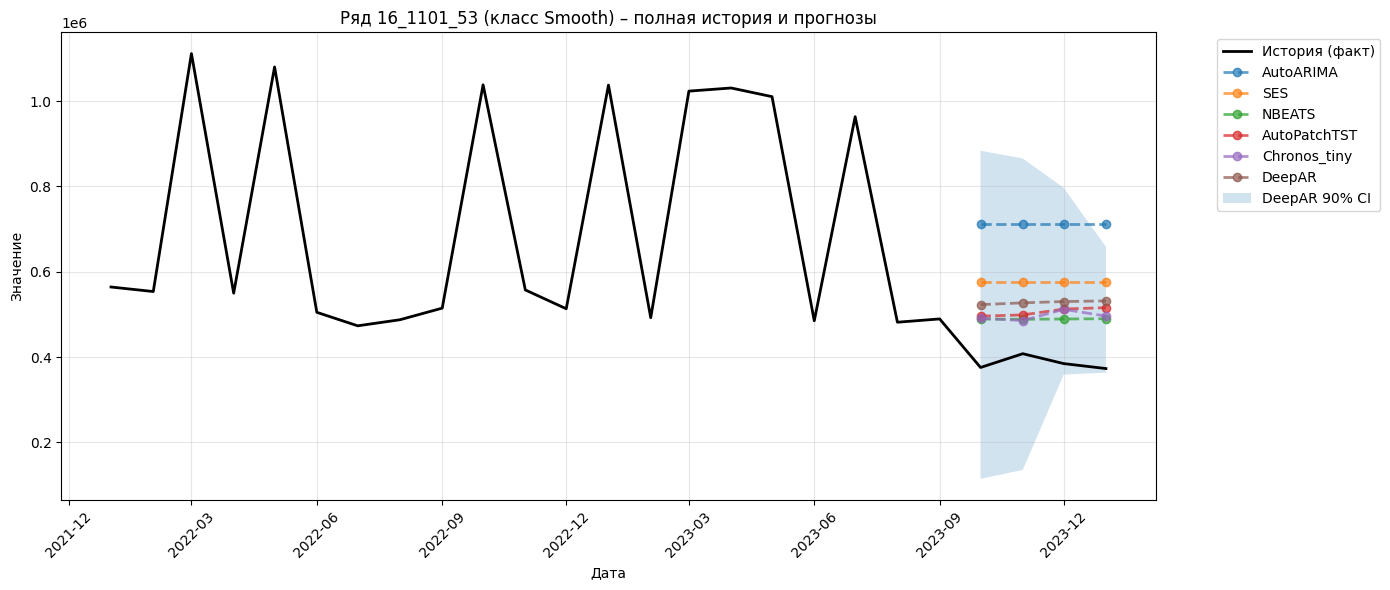

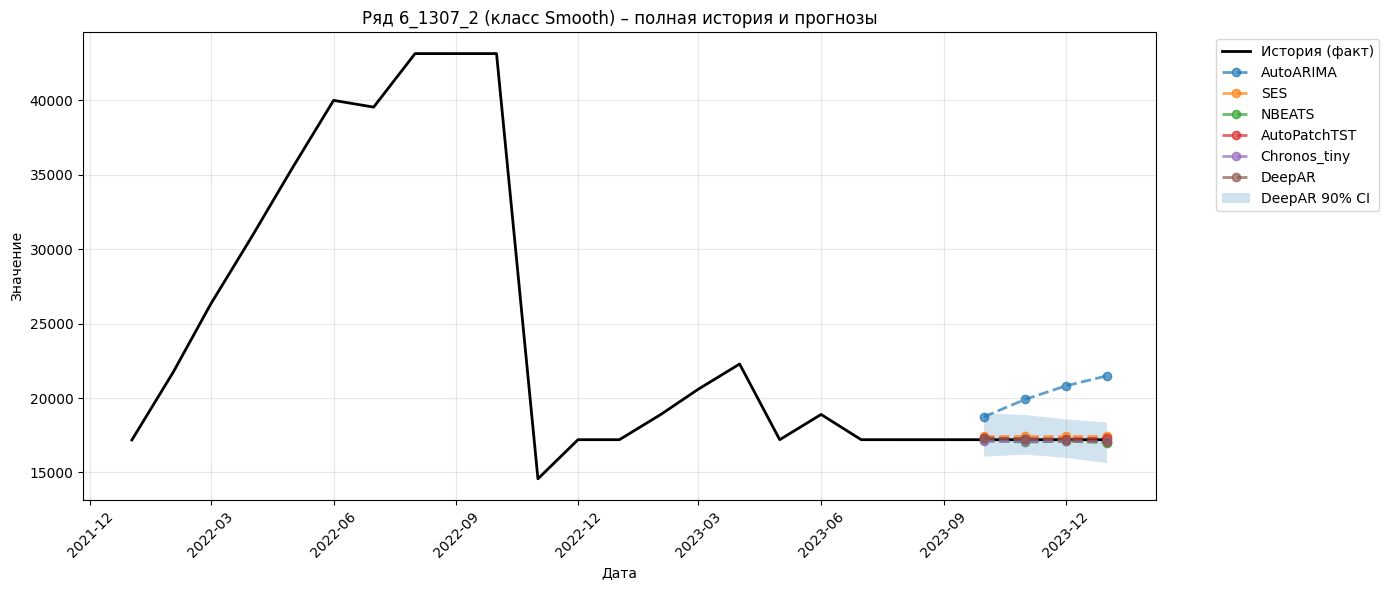

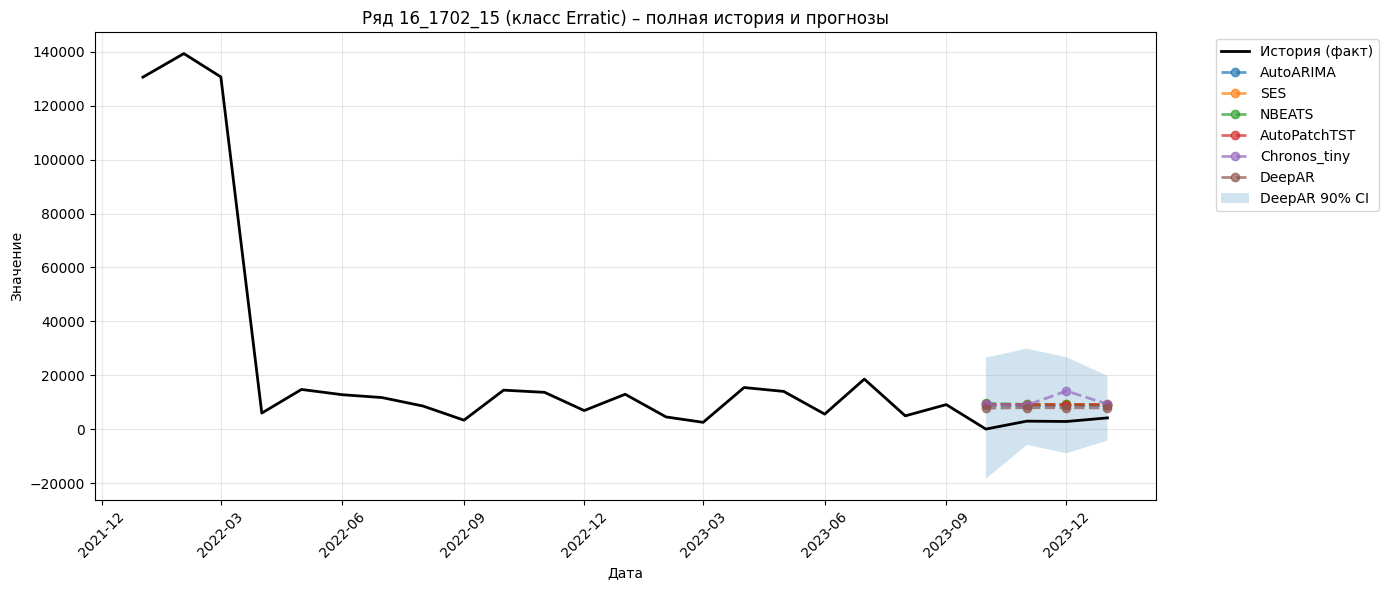

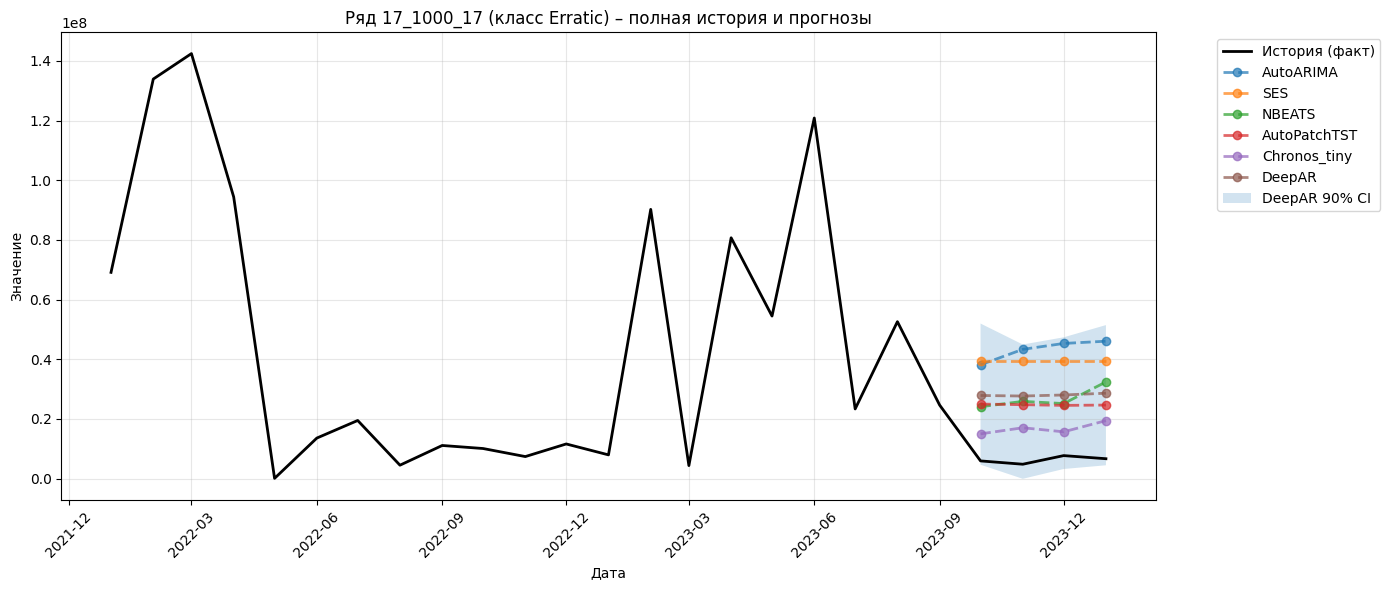

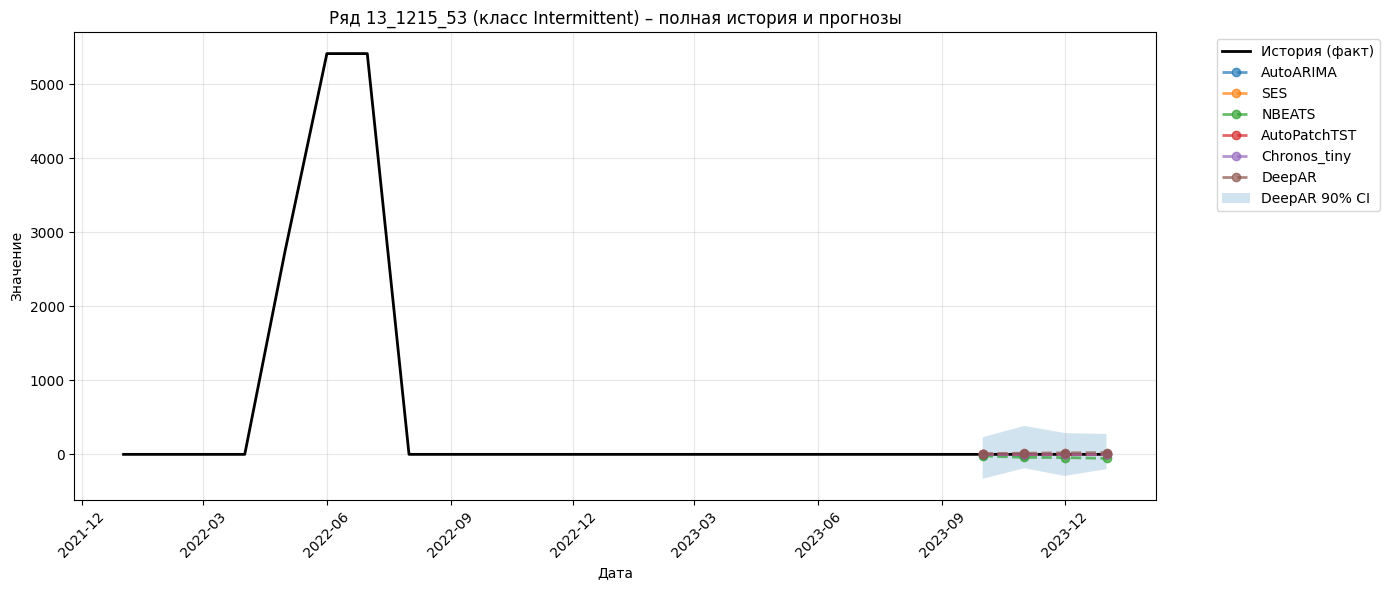

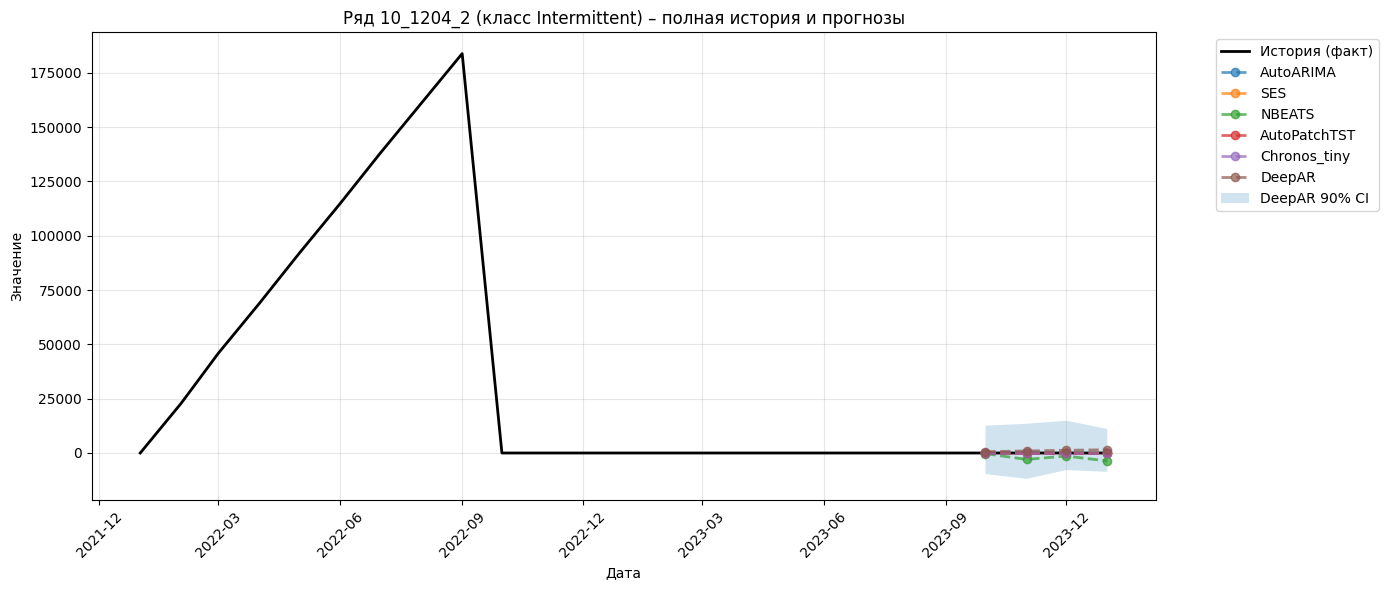

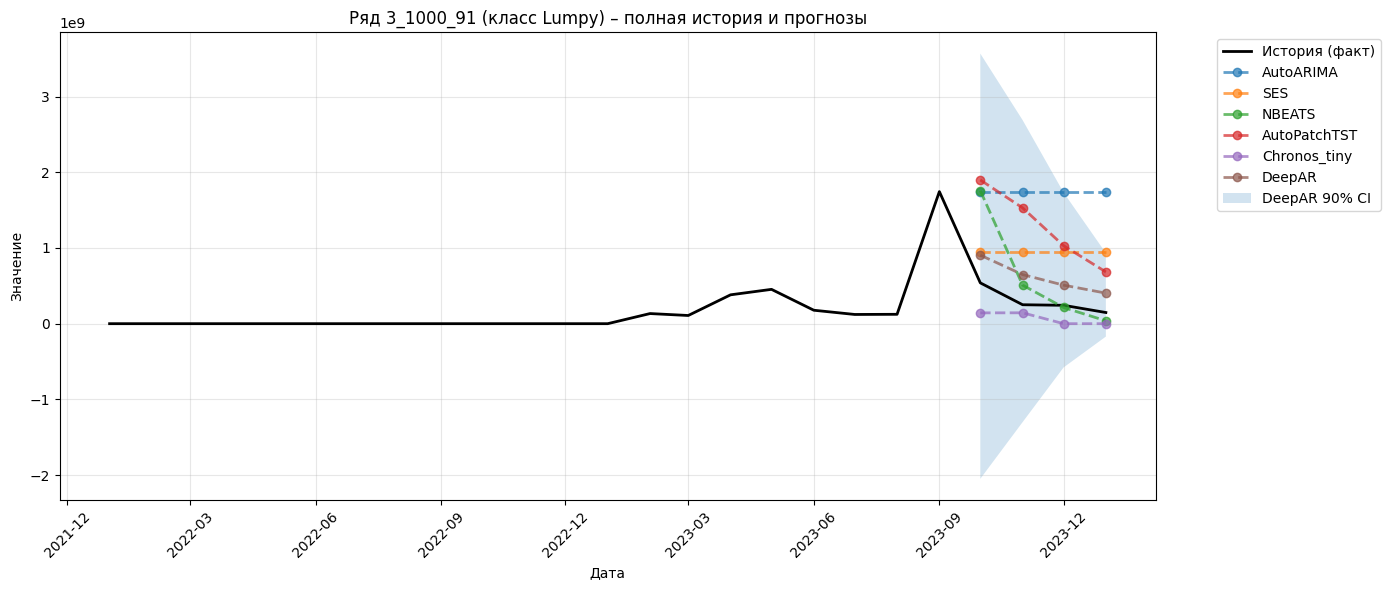

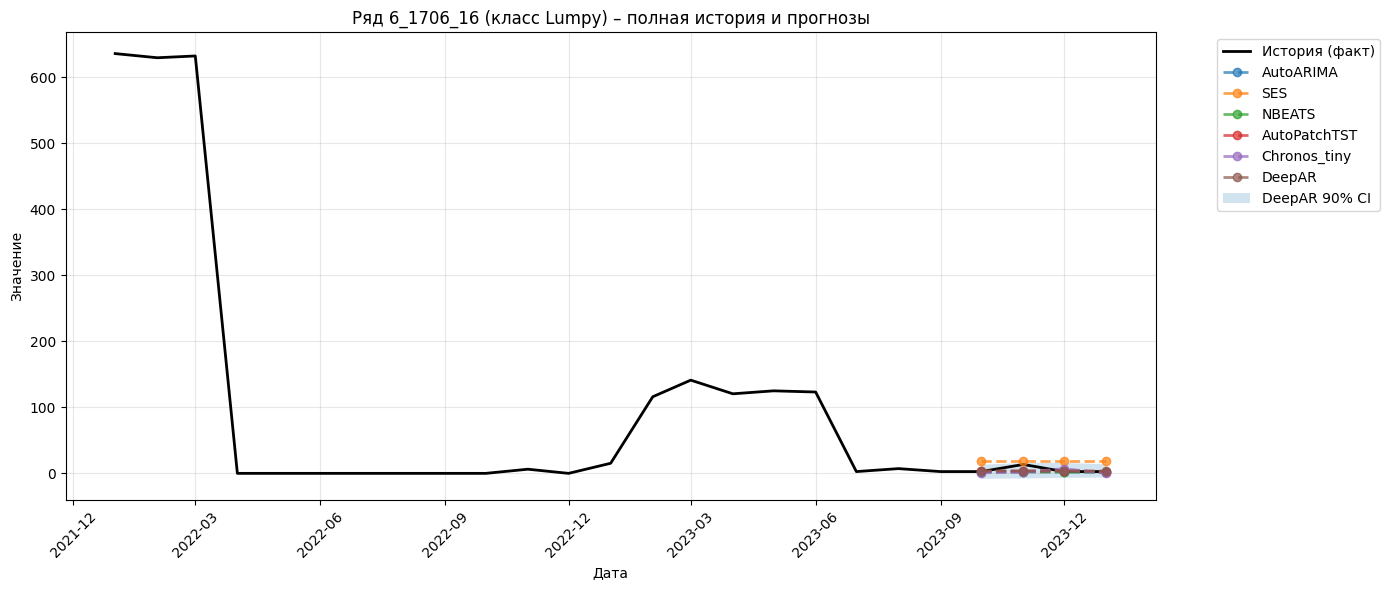

In [49]:
# Для каждого класса строим графики для выбранных рядов
for cls, ids in selected_series.items():
    if cls not in forecasts:
        continue
    forecast_df = forecasts[cls]
    for uid in ids:
        plot_full_series_with_forecast(
            uid, forecast_df, df_long, classification_df,
            models=['AutoARIMA', 'SES', 'NBEATS', 'AutoPatchTST', 'Chronos_tiny', 'DeepAR'],
            confidence_cols={'DeepAR': ('DeepAR-lo-90', 'DeepAR-hi-90')})

